In [23]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, activations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [6]:
X = df.drop('charges', axis=1)
y = df['charges']

In [7]:
cat_cols = ['sex', 'smoker', 'region']
num_cols = df.drop(['sex', 'smoker', 'region', 'charges'], axis=1).columns.tolist()

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

In [10]:
X_processed = preprocessor.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = keras.Sequential([
    layers.Dense(12, activation='relu'),
    layers.Dense(24, activation='relu'),
    layers.Dense(48, activation='relu'),
    layers.Dense(96, activation='relu'),
    layers.Dense(1) 
])

In [14]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [15]:
history = model.fit(X_train_scaled, y_train, batch_size=32, epochs=100) 

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 322392896.0000 - mae: 13343.8027
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321870432.0000 - mae: 13323.4443
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 318028800.0000 - mae: 13178.3857
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 299825216.0000 - mae: 12475.7549
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 244685008.0000 - mae: 10593.4678
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 155071872.0000 - mae: 8148.3169
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 102439624.0000 - mae: 7547.0000
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 80819416.0000 - mae: 6945.9331
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67601664.0000 - mae: 6475.1392
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 58072964.0000 - mae: 5907.6484
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 51495352.0000 - mae: 5692.1

In [16]:
y_pred = model.predict(X_test_scaled)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [17]:
y_true_flat = np.array(y_test).flatten()
y_pred_flat = y_pred.flatten()

In [20]:
# Metrics calculate
mae = mean_absolute_error(y_true_flat, y_pred_flat)

In [21]:
mae = mean_absolute_error(y_true_flat, y_pred_flat)
print("Test MAE:", mae)

Test MAE: 2754.666483627186


In [24]:
if len(y_true_flat) >= 2:
    r2 = r2_score(y_true_flat, y_pred_flat)
    print(f"R² Score: {r2:.4f}")
else:
    print("R² Score: Test set mein sirf 1 row hai, full dataset par R² auto-calculate ho jayega.")

R² Score: 0.8624


In [25]:
# plotting

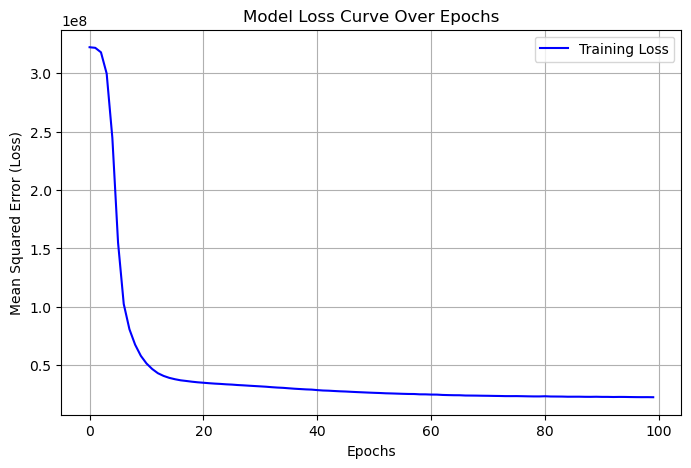

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
# Agar aap ne validation_split use kiya tha, to is line ko uncomment karein:
# plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')

plt.title('Model Loss Curve Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()


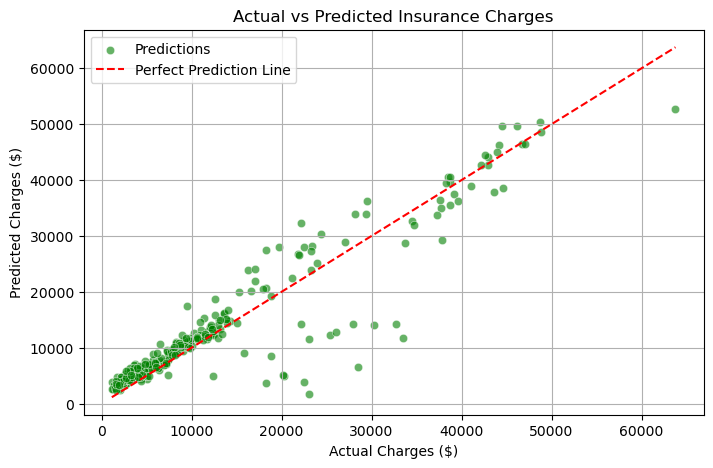

In [27]:
import seaborn as sns

plt.figure(figsize=(8, 5))
# Actual vs Predicted ka scatter plot
sns.scatterplot(x=y_true_flat, y=y_pred_flat, alpha=0.6, color='green', label='Predictions')

# Ek perfect prediction line (Diagonal line)
perfect_line = [min(y_true_flat), max(y_true_flat)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Prediction Line')

plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.grid(True)
plt.show()
